### [가장 긴 팰린드롬](https://school.programmers.co.kr/learn/courses/30/lessons/12904)

In [ ]:
def solution(s):
    N = len(s)
    
    for n in range(N, 2-1, -1):
        for i in range(N-n+1):
            target = s[i:i+n]
            if target == target[::-1]:
                return n
        
    return 1

### [풍선 터트리기](https://school.programmers.co.kr/learn/courses/30/lessons/68646?language=python3)

- left_min[i]: index 0부터 $i$까지 중 최솟값
- right_min[i]: index $i$부터 마지막까지 중 최솟값
- 풍선 $a[i]$가 살아남기 위한 조건: 
  - $a[i] < left\_min[i-1]$ 이거나 
  - $a[i] < right\_min[i+1]$ 이면 생존 가능 
  
(양 끝 풍선은 언제나 생존 가능하므로 결과값에 기본적으로 포함됨)

In [ ]:
def solution(a):
    n = len(a)
    if n <= 2:
        return n
    
    # 각 위치에서의 왼쪽 최솟값과 오른쪽 최솟값을 저장
    left_min = [0] * n
    right_min = [0] * n
    
    l_min = a[0]
    for i in range(n):
        if a[i] < l_min:
            l_min = a[i]
        left_min[i] = l_min
        
    r_min = a[-1]
    for i in range(n - 1, -1, -1):
        if a[i] < r_min:
            r_min = a[i]
        right_min[i] = r_min
        
    answer = 0
    for i in range(n):
        # 현재 풍선이 왼쪽 최솟값 혹은 오른쪽 최솟값보다 크다면 (둘 다보다 크면 불가능)
        if a[i] <= left_min[i] or a[i] <= right_min[i]:
            answer += 1
            
    return answer

`투 포인터(two pointer)를 이용해 풀이`
- 양 끝 풍선은 무조건 생존 가능하므로 answer = 2로 시작
- 왼쪽 포인터(l)와 오른쪽 포인터(r)를 두고, 현재까지 확인한 왼쪽 최솟값(l_min)과 오른쪽 최솟값(r_min)을 유지
- l_min과 r_min 중 더 큰 쪽을 안쪽으로 이동시키며 새로운 최솟값이 등장할 때마다 카운트

In [ ]:
def solution(a):
    n = len(a)
    if n <= 2:
        return n

    result = set([a[0], a[-1]])
    
    # 왼쪽에서 훑기
    cur_min = a[0]
    for i in range(1, n):
        if a[i] < cur_min:
            cur_min = a[i]
            result.add(cur_min)
            
    # 오른쪽에서 훑기
    cur_min = a[-1]
    for i in range(n - 2, -1, -1):
        if a[i] < cur_min:
            cur_min = a[i]
            result.add(cur_min)
            
    return len(result)

### [셔틀버스](https://school.programmers.co.kr/learn/courses/30/lessons/17678?language=python3)

In [ ]:
def solution(n, t, m, timetable):
    def to_min(time_str):
        h, m_unit = map(int, time_str.split(':'))
        return h * 60 + m_unit

    def to_str(time_min):
        return f"{time_min // 60:02d}:{time_min % 60:02d}"

    # 분 단위로 정렬된 크루 대기열
    timetable = sorted([to_min(x) for x in timetable])
    
    # 버스 시간표 생성 (분 단위)
    bus_times = [540 + i * t for i in range(n)]
    
    results = {}
    
    for bus_time in bus_times:
        results[bus_time] = []
        cnt = m
        # 버스 시간 이전에 도착한 크루를 정원만큼 태움
        while timetable and cnt > 0 and timetable[0] <= bus_time:
            results[bus_time].append(timetable.pop(0))
            cnt -= 1
            
    # 마지막 버스 정보 확인
    last_bus = bus_times[-1]
    last_crews = results[last_bus]
    
    # 2. 콘의 전략 결정
    if len(last_crews) < m:
        # 자리가 남으면 버스 도착 시간에 딱 맞춰 감
        answer = last_bus
    else:
        # 자리가 없으면 마지막으로 탄 크루보다 1분 빨리 감
        answer = last_crews[-1] - 1
        
    return to_str(answer)

### [거스름돈](https://school.programmers.co.kr/learn/courses/30/lessons/12907)

- 큰 단위의 돈부터 역산하는 방식으로 탐색하는 방법을 적용해봤지만 효율성 케이스를 통과하지 못함

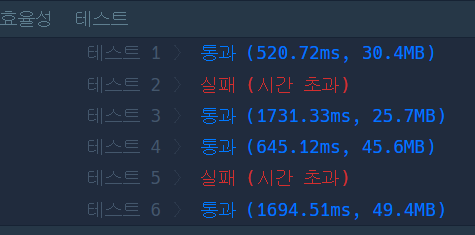

In [ ]:
def solution(n, money):
    # 큰 단위부터 계산하기 위해 내림차순 정렬
    money.sort(reverse=True)
    memo = {}

    def count_ways(remains, idx):
        # 목표 금액을 맞춘 경우
        if remains == 0:
            return 1
        # 금액을 초과했거나 더 이상 사용할 동전이 없는 경우
        if remains < 0 or idx >= len(money):
            return 0
        
        # 이미 계산한 적이 있는 상태라면 결과 반환 (Memoization)
        state = (remains, idx)
        if state in memo:
            return memo[state]
        
        res = 0
        current_coin = money[idx]
        # 현재 동전을 0개부터 최대한 사용할 수 있는 개수까지 반복
        for count in range(remains // current_coin + 1):
            res += count_ways(remains - (current_coin * count), idx + 1)
            
        memo[state] = res % 1_000_000_007
        return memo[state]

    return count_ways(n, 0)

- dp로 푸는 방식으로 접근  
  막상 코드는 어렵지 않은데, dp라는 접근방식을 떠올리고 이를 다른 관점에서 바라봐야하는게 쉽지가 않다...

In [ ]:
def solution(n, money):
    dp = [0] * (n + 1)
    dp[0] = 1 
    
    for m in money:
        for price in range(m, n + 1):
            dp[price] += dp[price - m]
        
    return dp[n] % 1_000_000_007

### [인사고과](https://school.programmers.co.kr/learn/courses/30/lessons/152995)

- 문제를 대충 읽었음...
- 어느 사원이 특정 사원에 대해 두 점수가 모두 낮은 경우가 한 번이라도 있다면 인센티브를 받지 못한다는 경우의 수를 고려해야함

In [ ]:
def solution(scores):
    N = len(scores)
    scores = [sum(x) for x in scores]
    ho = scores[0]    
    
    if ho == N*2: # 꼴등
        return -1
    
    scores.sort(reverse=True)
    
    for e, s in enumerate(scores, start=1):
        if s == ho:
            return e

- 유의사항을 고려해서 풀었으나, 일부 케이스에 대해 시간초과

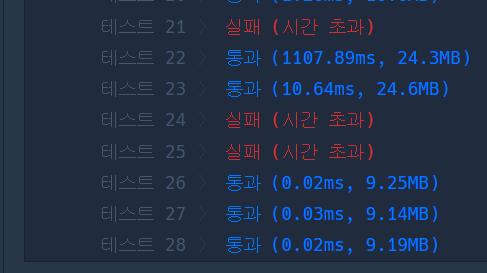

In [3]:
def solution(scores):
    idx = 0
    while True:
        a, b = scores[idx]
        no_incen = False
        for e, (c, d) in enumerate(scores):
            if idx == e:
                continue
            elif a < c and b < d:
                if idx == 0:
                    return -1
                scores.pop(idx)
                no_incen = True
                break
                
        if not no_incen:
            idx += 1
        if idx == len(scores):
            break
    scores = [sum(x) for x in scores]
    mine = scores[0]
    scores.sort(reverse=True)
    for e, s in enumerate(scores, start=1):
        if s == mine:
            return e

In [4]:
scores, result = [[2,2],[1,4],[3,2],[3,2],[2,1]], 4
solution(scores)

4

- 한 번의 스캔 과정에서 양방향(현재 근로자가 다른 근로자보다 모두 낮은 경우와 모든 높은 경우를 동시에) 비교를 하려 했으나 fail
- 로직만 보려 적당히 수정하긴 했지만, 여전히 시간초과

In [ ]:
def solution(scores):
    idx = 0
    while True:
        a, b = scores[idx]
        no_incen = False
        smallers = [] # 현재 대상자보다 점수가 낮은 사람들
        for e, (c, d) in enumerate(scores):
            if idx == e:
                continue
            elif a < c and b < d:
                if idx == 0:
                    return -1
                smallers.append(e)
            elif a > c and b > d:
                smallers.append(e)
        
        if smallers:
            for i in reversed(smallers):
                scores.pop(i)
                idx -= 1
                
        idx += 1
        if idx == len(scores):
            break
    scores = [sum(x) for x in scores]
    mine = scores[0]
    scores.sort(reverse=True)
    for e, s in enumerate(scores, start=1):
        if s == mine:
            return e